# Adding the Barotropic Current to SOMISANA Forecasts

**A supplement to `02_SOMISANA_forecast_tutorial.ipynb`**

If you use Colab instead of your local computer do File → Save a copy in Drive, right after opening the Colab link, so your changes are saved.

In the Day 2 tutorial the **total** current was not straight forward. This notebook explains why, and shows how to reconstruct the total surface current using the raw CROCO output.

## The problem

CROCO (like most ocean models) splits the current into two parts:

- **Barotropic** — the depth-averaged flow, driven mainly by tides, wind set-up, and large-scale pressure gradients. It is (by definition) the same at every depth.
- **Baroclinic** — the depth-*varying* part left over once the barotropic (depth-average) is removed, driven mainly by density (temperature/salinity) gradients.

$$\text{total current} = \text{barotropic} + \text{baroclinic}$$

The tier-3 files you used on Day 2 (`croco_avg_t3.nc` / `croco_avg_t3_day.nc`) only contain the **baroclinic** part — you can see this in their own metadata:

```python
ds_t3.u.attrs["standard_name"]
# -> 'baroclinic_eastward_sea_water_velocity'
```

The barotropic component (`ubar`, `vbar`) only exists in the **raw** model output (`croco_avg.nc`). That file is also on CROCO's native **curvilinear, rotated** model grid rather than the plain lon/lat grid of the tier-3 product, so getting the two pieces onto a common grid takes a bit of extra work. That's what this notebook walks through.

## What this notebook does
1. Load the baroclinic surface current from the tier-3 product (same as Day 2, Section 8).
2. Load the barotropic current (`ubar`, `vbar`) from the raw output via OPeNDAP.
3. Move `ubar`/`vbar` from their native staggered grid points onto the rho (cell-centre) grid, and **rotate** them from grid-relative to true east/north using the grid's `angle` variable.
4. **Regrid** the (curvilinear) barotropic field onto the tier-3 product's regular lon/lat grid.
5. Add barotropic + baroclinic to get the **total** surface current, and compare it to the baroclinic-only map from Day 2.


## 1. Setup

In [1]:
# Run once per environment (e.g. once per Colab session, or once in your local conda/venv)
%pip install -q numpy scipy xarray matplotlib cartopy netCDF4 pandas


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata

%matplotlib inline
plt.rcParams["figure.dpi"] = 100


## 2. Connect to a forecast cycle via OPeNDAP

We'll pull both the tier-3 product and the raw output from the **same forecast cycle and the same hourly time step**, so the baroclinic and barotropic pieces we combine are guaranteed to be consistent with each other. See the OPeNDAP appendix in `02_SOMISANA_forecast_tutorial.ipynb` for how to find a `cycle` folder name of your own via the Thredds catalog (https://catalog.somisana.ac.za/catalog/).


In [3]:
OPENDAP_REGIONS = {"SA-West": "sa-west", "SA-East": "sa-southeast"}
OPENDAP_BASE = "https://somisana.ocean.gov.za/thredds/dodsC/mnt/ocims-somisana/public-facing"


def opendap_url(region, config, cycle, filename):
    '''Build the OPeNDAP URL for a SOMISANA forecast file.

    `cycle` is a forecast-cycle folder name found by browsing the Thredds
    catalog, e.g. "20260906_00".
    '''
    server_region = OPENDAP_REGIONS[region]
    return f"{OPENDAP_BASE}/{server_region}/v1.0/forecasts/{cycle}/{config}/{filename}"


# TODO: update these to a cycle/region/config you want to look at
cycle = "20260906_00"
region = "SA-West"
config = "HYCOM-GFS"
time_step = 0  # hourly index into the forecast cycle

url_t3 = opendap_url(region, config, cycle, "croco_avg_t3.nc")
url_raw = opendap_url(region, config, cycle, "croco_avg.nc")
print("tier-3 (baroclinic):", url_t3)
print("raw (barotropic):   ", url_raw)


tier-3 (baroclinic): https://somisana.ocean.gov.za/thredds/dodsC/mnt/ocims-somisana/public-facing/sa-west/v1.0/forecasts/20260906_00/HYCOM-GFS/croco_avg_t3.nc
raw (barotropic):    https://somisana.ocean.gov.za/thredds/dodsC/mnt/ocims-somisana/public-facing/sa-west/v1.0/forecasts/20260906_00/HYCOM-GFS/croco_avg.nc


## 3. Baroclinic surface current (tier-3 product)

This is exactly what Day 2, Section 8 used — surface (`depth=0`) `u`/`v` from the tier-3 file, already on a regular lon/lat grid and already rotated to true east/north.


In [4]:
ds_t3 = xr.open_dataset(url_t3)

print(ds_t3.u.attrs)  # note standard_name: baroclinic_eastward_sea_water_velocity

baroclinic_u = ds_t3.u.isel(time=time_step, depth=0).load()
baroclinic_v = ds_t3.v.isel(time=time_step, depth=0).load()
baroclinic_speed = np.sqrt(baroclinic_u ** 2 + baroclinic_v ** 2)


{'long_name': 'Eastward component of baroclinic velocity', 'units': 'm s-1', 'standard_name': 'baroclinic_eastward_sea_water_velocity', '_ChunkSizes': array([240,   1, 350, 276], dtype=int32)}


## 4. Barotropic current (raw output)

Now open the raw file and inspect its grid. Unlike the tier-3 product, this is CROCO's native **Arakawa C-grid**: `u`/`ubar` live at u-points (offset half a cell in the `xi` direction from the rho/cell-centre points), and `v`/`vbar` live at v-points (offset half a cell in `eta`). `lon_rho`/`lat_rho` (and their `_u`/`_v` counterparts) are 2-D curvilinear coordinate arrays, not simple 1-D lon/lat vectors — this is a rotated, terrain-following model grid, not a plain lat/lon grid.


In [5]:
ds_raw = xr.open_dataset(url_raw)

print(ds_raw.ubar.attrs)  # 'averaged vertically integrated u-momentum component' -- the barotropic mode
print(ds_raw.angle.attrs)  # rotation of the model grid relative to true east, in radians

ubar = ds_raw.ubar.isel(time=time_step).load()   # (eta_rho, xi_u)
vbar = ds_raw.vbar.isel(time=time_step).load()   # (eta_v, xi_rho)
angle = ds_raw.angle.load()                       # (eta_rho, xi_rho), radians
lon_rho = ds_raw.lon_rho.load()
lat_rho = ds_raw.lat_rho.load()
mask_rho = ds_raw.mask_rho.load()                 # 1 = ocean, 0 = land


{'long_name': 'averaged vertically integrated u-momentum component', 'units': 'meter second-1', 'field': 'ubar-velocity, scalar, series', 'standard_name': 'barotropic_sea_water_x_velocity_at_u_location'}
{'long_name': 'angle between XI-axis and EAST', 'units': 'radians', 'field': 'angle, scalar'}


## 5. Move `ubar`/`vbar` onto the rho grid, and rotate to true east/north

Two steps are needed before `ubar`/`vbar` are directly comparable to the tier-3 `u`/`v`:

1. **Interpolate onto rho-points.** A u-point sits halfway between the two rho-points either side of it (and similarly for v-points), so a simple average of the two neighbours gets us onto the rho grid (the two edge columns/rows, which have no inner neighbour on one side, are just carried across unchanged — a minor approximation that's fine for a broad-scale current map).
2. **Rotate.** `ubar`/`vbar` point along the model grid's own (rotated) `xi`/`eta` axes, not along true east/north. The `angle` variable (grid rotation relative to true east, in radians) lets us rotate them into true eastward/northward components — exactly like the tier-3 processing already did for `u`/`v`.


In [6]:
def to_rho_points_xi(field):
    '''Average a field from u-points onto rho-points along the xi (last) axis.'''
    field = np.asarray(field)
    rho = np.empty((field.shape[0], field.shape[1] + 1))
    rho[:, 1:-1] = 0.5 * (field[:, :-1] + field[:, 1:])
    rho[:, 0] = field[:, 0]
    rho[:, -1] = field[:, -1]
    return rho


def to_rho_points_eta(field):
    '''Average a field from v-points onto rho-points along the eta (first) axis.'''
    field = np.asarray(field)
    rho = np.empty((field.shape[0] + 1, field.shape[1]))
    rho[1:-1, :] = 0.5 * (field[:-1, :] + field[1:, :])
    rho[0, :] = field[0, :]
    rho[-1, :] = field[-1, :]
    return rho


ubar_rho = to_rho_points_xi(ubar.values)
vbar_rho = to_rho_points_eta(vbar.values)

angle_rho = angle.values
ubar_east = ubar_rho * np.cos(angle_rho) - vbar_rho * np.sin(angle_rho)
vbar_north = ubar_rho * np.sin(angle_rho) + vbar_rho * np.cos(angle_rho)


## 6. Regrid the barotropic current onto the tier-3 grid

The barotropic field is still on the native **curvilinear** rho grid (`lon_rho`, `lat_rho` are 2-D). This is a different situation from the horizontal regridding in `03_own_region_project.ipynb`, where both grids were plain 1-D lon/lat grids and `xarray.interp_like()` was enough — here the source grid is curvilinear, so we treat it as a cloud of scattered `(lon, lat)` points and use `scipy.interpolate.griddata` instead. We mask out land points first so they don't leak into the interpolation.


In [7]:
ocean = mask_rho.values > 0
points = np.column_stack([lon_rho.values[ocean], lat_rho.values[ocean]])

lon_t3, lat_t3 = np.meshgrid(baroclinic_u.longitude.values, baroclinic_u.latitude.values)

ubar_on_t3 = griddata(points, ubar_east[ocean], (lon_t3, lat_t3), method="linear")
vbar_on_t3 = griddata(points, vbar_north[ocean], (lon_t3, lat_t3), method="linear")


## 7. Total current = barotropic + baroclinic

Now that both pieces are on the same grid and both point true east/north, we can just add them.


/var/folders/xx/yfv8g48909qbhg0jw1wqbph80000gt/T/ipykernel_80779/1429331066.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.08, 1, 0.96])


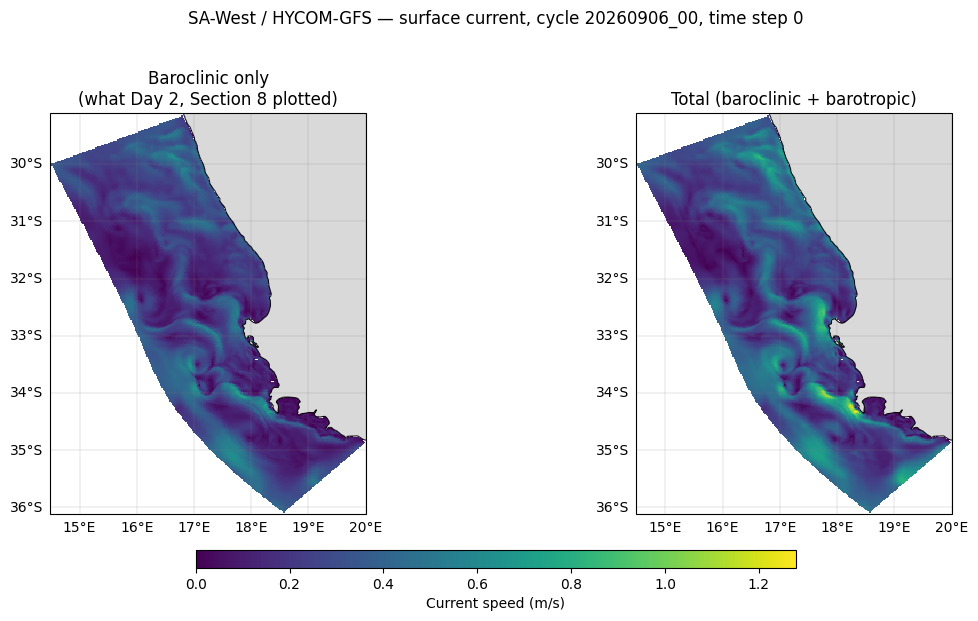

In [8]:
total_u = baroclinic_u.values + ubar_on_t3
total_v = baroclinic_v.values + vbar_on_t3
total_speed = np.sqrt(total_u ** 2 + total_v ** 2)


def plot_field(ax, lon, lat, data, cmap="viridis", vmin=None, vmax=None, add_colorbar=True, **kwargs):
    '''Convenience wrapper to plot a 2D (lat, lon) field with cartopy coastlines.'''
    im = ax.pcolormesh(
        lon, lat, data, transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax,
        shading="auto", **kwargs,
    )
    ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=2)
    ax.coastlines(resolution="10m", linewidth=0.7, zorder=3)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="0.5", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    if add_colorbar:
        plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
    return im


vmax = float(np.nanmax([baroclinic_speed.values, total_speed]))
fig, axes = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={"projection": ccrs.PlateCarree()})

im0 = plot_field(axes[0], baroclinic_u.longitude, baroclinic_u.latitude, baroclinic_speed, vmin=0, vmax=vmax, add_colorbar=False)
axes[0].set_title("Baroclinic only\n(what Day 2, Section 8 plotted)")

im1 = plot_field(axes[1], baroclinic_u.longitude, baroclinic_u.latitude, total_speed, vmin=0, vmax=vmax, add_colorbar=False)
axes[1].set_title("Total (baroclinic + barotropic)")

cax = fig.add_axes([0.25, 0.05, 0.5, 0.03])
fig.colorbar(im1, cax=cax, orientation="horizontal", label="Current speed (m/s)")
fig.suptitle(f"{region} / {config} — surface current, cycle {cycle}, time step {time_step}")
fig.tight_layout(rect=[0, 0.08, 1, 0.96])


## Notes
- **Any depth, not just the surface.** The barotropic current is by definition the *same at every depth*, so you can add `ubar_on_t3`/`vbar_on_t3` to the tier-3 baroclinic `u`/`v` at **any** `depth` index (not just `depth=0`) to get the total current at that depth — repeat Section 3 and 7 with a different `.isel(depth=...)`.
- **Daily-mean totals.** This notebook combines a single matched *hourly* time step so the two pieces are guaranteed consistent. If you want a total current to go with the pre-downloaded **daily-mean** tier-3 files from Day 2 (`croco_avg_t3_day.nc`), you'll need a daily-mean barotropic field too — e.g. open `croco_avg.nc` over 24 hourly steps for one day (`.isel(time=slice(0, 24))`) and take `.mean("time")` of `ubar`/`vbar` before rotating/regridding.
- **Approximations used here.** The edge columns/rows in the u-point → rho-point and v-point → rho-point averaging are carried across unchanged rather than properly extrapolated, and the curvilinear regrid uses simple linear interpolation. Both are fine for a broad-scale current map but introduce small errors right at the domain edge — for research-quality work, a dedicated tool such as [`xesmf`](https://xesmf.readthedocs.io/) (mentioned in `03_own_region_project.ipynb`) or CROCO's own grid utilities would be more rigorous.